# Assignment 5: Autoencoders

**Objective:**
To store a set of images using a minimal amount of data by training an autoencoder on handwritten Arabic digits. 

**Data:**
Dataset obtained from Arabic Handwritten Digits Dataset | Kaggle. Original source unknown. The dataset file is attached below for download. 

**Problem Statement:**
You are part of a team developing a mobile app for performing arithmetic with handwritten Arabic digits. The app will recognize digits in the user’s handwriting. Your task as a developer is to encode each hand-drawn digit using as little memory as possible while preserving the ability to reconstruct the images. Using the dataset of handwritten Arabic digits, you will train an autoencoder to encode and decode these images efficiently.

**Arabic Digits:**
Arabic digits correspond to Roman digits as described in N. Das, A. Mollah, S. Saha, S. Haque, 2010 (https://arxiv.org/abs/1003.1891).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from keras.models import Model
from keras.layers import Input, Dense
 
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

Using TensorFlow backend.



# Data
a. Each row of csvImages 10k x 784.csv contains the grayscale values of a 28×28 image. Load this data into a pandas DataFrame and convert it to a NumPy array using pandas.values. Print the shape of the data.


In [2]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/csvImages_10k_x_784.csv"
Arabic_data = pd.read_csv(url, header=None)
Arabic_data.shape

(10000, 784)

In [3]:
Arabic_array = Arabic_data.values
Arabic_array.shape

(10000, 784)


b. Normalize the values by dividing by 255. To display the images, reshape each array to 28×28 using numpy.ndarray.reshape. Use matplotlib.pyplot.imshow and matplotlib.pyplot.subplot to plot the first five images using the 'gray' colormap.


In [4]:
normalized_data = Arabic_array.astype('float32') / 255.0
normalized_data.reshape(10000, 28, 28)

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

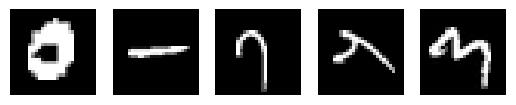

In [5]:
# Plot first 5 images
for i in range(5):
    # Reshape to 28x28
    image = normalized_data[i].reshape(28, 28)
    
    # Create subplot
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()


c. To prepare the data for input to the neural network, reshape each image back into a one-dimensional array of size 784.


In [6]:
images = normalized_data.reshape((-1, 28 ** 2))
images.shape

(10000, 784)

# Modeling
a. Use keras.layers to create an input layer matching the dimensions of your data. 


In [9]:
input_layer = Input(shape=(784,))


b. Use keras.layers to create an encoding stage with at least two layers that reduces the data size to 50% or less (smaller is better). Choose appropriate activation functions.


In [10]:
hidden_encoding = Dense(392, activation='relu')(input_layer)
encoding_stage = Dense(196, activation='relu')(hidden_encoding)


c. Use keras.layers to create a decoding stage with at least two layers that restores the data to its original size. Choose appropriate activation functions. 


In [11]:
hidden_decoding = Dense(392, activation='relu')(encoding_stage)
decoding_stage = Dense(784, activation='sigmoid')(hidden_decoding)

d. Compile the complete autoencoder network, selecting a suitable loss function and optimizer, and train the network on the image data. 


In [12]:
autoencoder = Model(input_layer, decoding_stage)

autoencoder.compile(loss='binary_crossentropy',
              optimizer='adadelta')
autoencoder.fit(images, images, epochs=10)

Epoch 1/10
10000/10000 [==============================] - 8s 763us/step - loss: 0.2869
Epoch 2/10
10000/10000 [==============================] - 5s 524us/step - loss: 0.1952
Epoch 3/10
10000/10000 [==============================] - 5s 471us/step - loss: 0.1587
Epoch 4/10
10000/10000 [==============================] - 5s 460us/step - loss: 0.1418
Epoch 5/10
10000/10000 [==============================] - 5s 466us/step - loss: 0.1302
Epoch 6/10
10000/10000 [==============================] - 5s 467us/step - loss: 0.1217
Epoch 7/10
10000/10000 [==============================] - 4s 448us/step - loss: 0.1149
Epoch 8/10
10000/10000 [==============================] - 4s 449us/step - loss: 0.1094
Epoch 9/10
10000/10000 [==============================] - 5s 463us/step - loss: 0.1047
Epoch 10/10
10000/10000 [==============================] - 6s 557us/step - loss: 0.1010


e. Compile the encoder network using your trained input layer and encoding stage. 


In [13]:
encoder_output = Model(input_layer, encoding_stage).predict(images[:5])
encoder_output.shape

(5, 196)

In [14]:
# Reshape the encoder output to 14x14 and scale back to [0, 255] for visualization
encoder_output = encoder_output.reshape((-1, 14, 14)) * 255

In [15]:
decoder_output = autoencoder.predict(images[:5])
decoder_output = decoder_output.reshape((-1, 28, 28)) * 255

In [16]:
images = images.reshape((-1, 28, 28))


# Conclusions
a. Use matplotlib.plot.imshow, matplotlib.plot.subplot, and your trained models to plot the first five original images along the top row, the encoded versions along the second row, and the decoded versions along the bottom row.


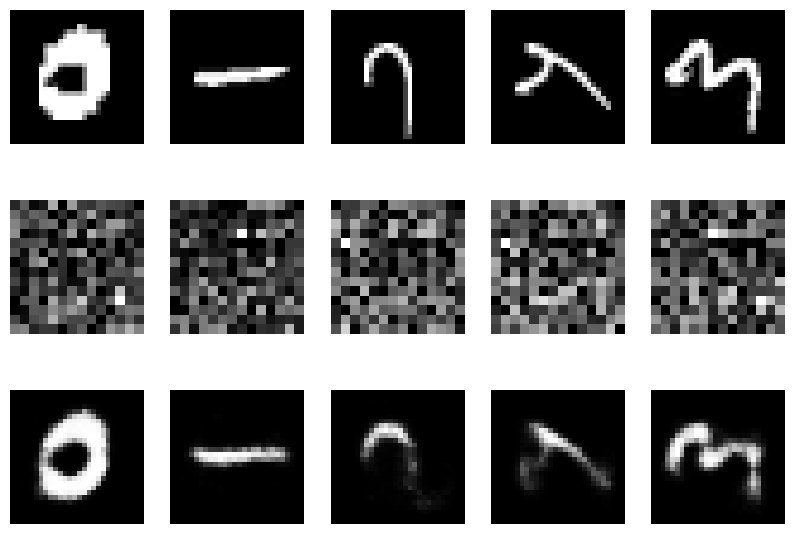

In [ ]:
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot the original image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output[i], cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output[i], cmap='gray')
    plt.axis('off')  


b. Adjust the hyperparameters of your model as needed to produce decoded images that closely represent the originals while minimizing the encoding size. Record all adjustments in Markdown.


### 784→392→196 50 Epochs

Epoch 1/50
10000/10000 [==============================] - 5s 488us/step - loss: 0.2887
Epoch 2/50
10000/10000 [==============================] - 4s 439us/step - loss: 0.1952
Epoch 3/50
10000/10000 [==============================] - 4s 438us/step - loss: 0.1599
Epoch 4/50
10000/10000 [==============================] - 4s 440us/step - loss: 0.1427
Epoch 5/50
10000/10000 [==============================] - 4s 419us/step - loss: 0.1299
Epoch 6/50
10000/10000 [==============================] - 4s 445us/step - loss: 0.1202
Epoch 7/50
10000/10000 [==============================] - 4s 423us/step - loss: 0.1135
Epoch 8/50
10000/10000 [==============================] - 4s 448us/step - loss: 0.1081
Epoch 9/50
10000/10000 [==============================] - 4s 447us/step - loss: 0.1039
Epoch 10/50
10000/10000 [==============================] - 5s 487us/step - loss: 0.1002
Epoch 11/50
10000/10000 [==============================] - 5s 500us/step - loss: 0.0974
Epoch 12/50
10000/10000 [================

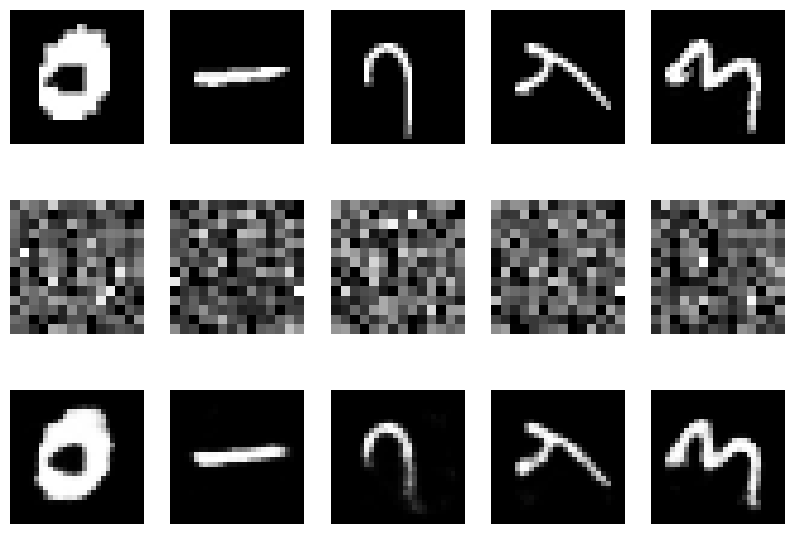

In [ ]:
images = normalized_data.reshape((-1, 28 ** 2))
# Redefining Input Layer
input_layer = Input(shape=(784,))
# Encoding Stage
hidden_encoding = Dense(392, activation='relu')(input_layer)
encoding_stage = Dense(196, activation='relu')(hidden_encoding)
#Decoding Stage
hidden_decoding = Dense(392, activation='relu')(encoding_stage)
decoding_stage = Dense(784, activation='sigmoid')(hidden_decoding)
# Training
autoencoder = Model(input_layer, decoding_stage)
autoencoder.compile(loss='binary_crossentropy',
              optimizer='adadelta')
autoencoder.fit(images, images, epochs=50)
# Storing the encoder output
encoder_output = Model(input_layer, encoding_stage).predict(images[:5])
encoder_output = encoder_output.reshape((-1, 14, 14)) * 255
# Storing the decoder output
decoder_output = autoencoder.predict(images[:5])
decoder_output = decoder_output.reshape((-1, 28, 28)) * 255
# Reshaping for Visualization Purposes
images = images.reshape((-1, 28, 28))

# Plot the original, encoded, and decoded images
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot the original image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output[i], cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output[i], cmap='gray')
    plt.axis('off')  

### 784→128→64 100 Epochs

Epoch 1/100
10000/10000 [==============================] - 2s 233us/step - loss: 0.3107
Epoch 2/100
10000/10000 [==============================] - 2s 196us/step - loss: 0.2160
Epoch 3/100
10000/10000 [==============================] - 2s 193us/step - loss: 0.1842
Epoch 4/100
10000/10000 [==============================] - 2s 199us/step - loss: 0.1603
Epoch 5/100
10000/10000 [==============================] - 2s 195us/step - loss: 0.1491
Epoch 6/100
10000/10000 [==============================] - 2s 170us/step - loss: 0.1394
Epoch 7/100
10000/10000 [==============================] - 2s 206us/step - loss: 0.1321
Epoch 8/100
10000/10000 [==============================] - 2s 217us/step - loss: 0.1268
Epoch 9/100
10000/10000 [==============================] - 2s 229us/step - loss: 0.1221
Epoch 10/100
10000/10000 [==============================] - 2s 210us/step - loss: 0.1186
Epoch 11/100
10000/10000 [==============================] - 2s 179us/step - loss: 0.1153
Epoch 12/100
10000/10000 [====

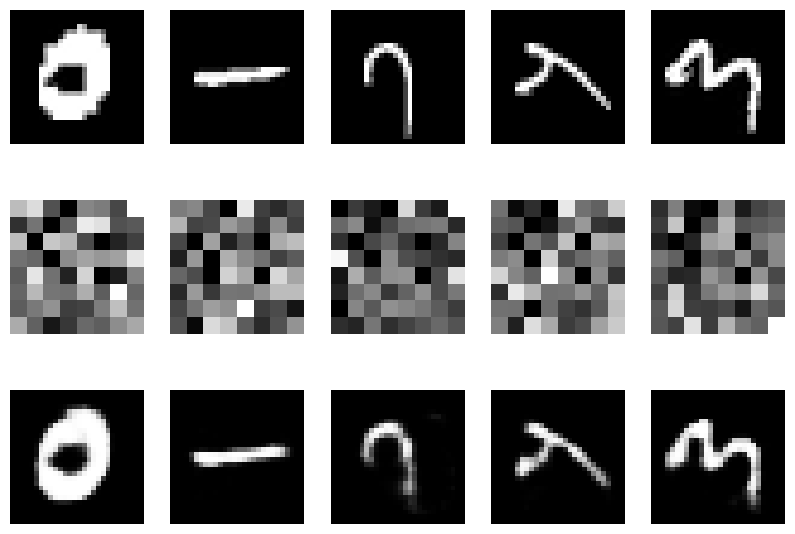

In [15]:
images = normalized_data.reshape((-1, 28 ** 2))
# Redefining Input Layer
input_layer = Input(shape=(784,))
# Encoding Stage
hidden_encoding = Dense(128, activation='relu')(input_layer)
encoding_stage = Dense(64, activation='relu')(hidden_encoding)
#Decoding Stage
hidden_decoding = Dense(128, activation='relu')(encoding_stage)
decoding_stage = Dense(784, activation='sigmoid')(hidden_decoding)
# Training
autoencoder = Model(input_layer, decoding_stage)
autoencoder.compile(loss='binary_crossentropy',
              optimizer='adadelta')
autoencoder.fit(images, images, epochs=100)
# Storing the encoder output
encoder_output = Model(input_layer, encoding_stage).predict(images[:5])
encoder_output = encoder_output.reshape((-1, 8, 8)) * 255
# Storing the decoder output
decoder_output = autoencoder.predict(images[:5])
decoder_output = decoder_output.reshape((-1, 28, 28)) * 255
# Reshaping for Visualization Purposes
images = images.reshape((-1, 28, 28))

# Plot the original, encoded, and decoded images
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot the original image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output[i], cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output[i], cmap='gray')
    plt.axis('off')  

### 784→64→32 100 Epochs

Epoch 1/100
10000/10000 [==============================] - 2s 178us/step - loss: 0.3263
Epoch 2/100
10000/10000 [==============================] - 2s 153us/step - loss: 0.2255
Epoch 3/100
10000/10000 [==============================] - 2s 160us/step - loss: 0.1977
Epoch 4/100
10000/10000 [==============================] - 2s 167us/step - loss: 0.1782
Epoch 5/100
10000/10000 [==============================] - 2s 174us/step - loss: 0.1627
Epoch 6/100
10000/10000 [==============================] - 2s 157us/step - loss: 0.1511
Epoch 7/100
10000/10000 [==============================] - 2s 156us/step - loss: 0.1434
Epoch 8/100
10000/10000 [==============================] - 2s 151us/step - loss: 0.1385
Epoch 9/100
10000/10000 [==============================] - 2s 162us/step - loss: 0.1346
Epoch 10/100
10000/10000 [==============================] - 2s 150us/step - loss: 0.1308
Epoch 11/100
10000/10000 [==============================] - 2s 152us/step - loss: 0.1273
Epoch 12/100
10000/10000 [====

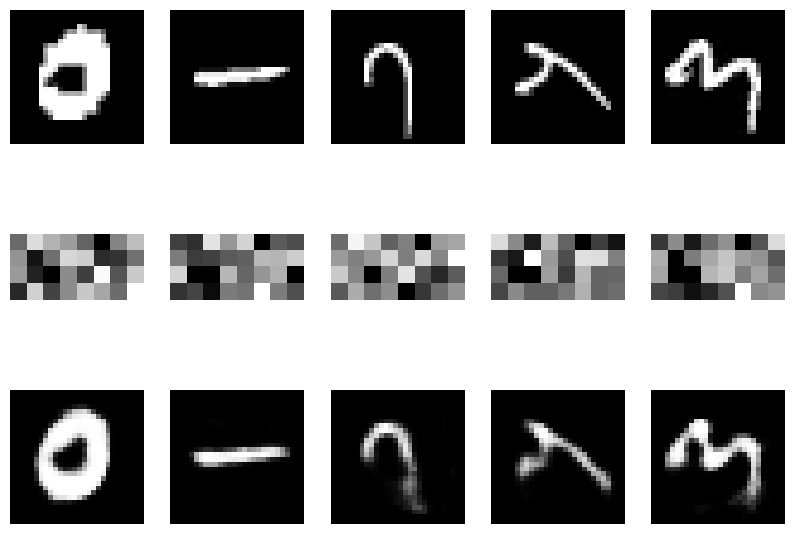

In [16]:
images = normalized_data.reshape((-1, 28 ** 2))
# Redefining Input Layer
input_layer = Input(shape=(784,))
# Encoding Stage
hidden_encoding = Dense(64, activation='relu')(input_layer)
encoding_stage = Dense(32, activation='relu')(hidden_encoding)
#Decoding Stage
hidden_decoding = Dense(64, activation='relu')(encoding_stage)
decoding_stage = Dense(784, activation='sigmoid')(hidden_decoding)
# Training
autoencoder = Model(input_layer, decoding_stage)
autoencoder.compile(loss='binary_crossentropy',
              optimizer='adadelta')
autoencoder.fit(images, images, epochs=100)
# Storing the encoder output
encoder_output = Model(input_layer, encoding_stage).predict(images[:5])
encoder_output = encoder_output.reshape((-1, 4, 8)) * 255
# Storing the decoder output
decoder_output = autoencoder.predict(images[:5])
decoder_output = decoder_output.reshape((-1, 28, 28)) * 255
# Reshaping for Visualization Purposes
images = images.reshape((-1, 28, 28))

# Plot the original, encoded, and decoded images
plt.figure(figsize=(10, 7))
for i in range(5):
    # Plot the original image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
    
    # Plot the encoder output
    plt.subplot(3, 5, i + 6)
    plt.imshow(encoder_output[i], cmap='gray')
    plt.axis('off')   
    
    # Plot the decoder output
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoder_output[i], cmap='gray')
    plt.axis('off')  

### Adjustments:
- We started with a 784 -> 392 -> 196 encoding, using 10 epochs. The very first results showed us that the model was running successfully and showed images that made sense at a first sight.
- Then, we increased the epochs to 50 as the loss was consistently going down and we wanted to see what results we would get with the same bottleneck size. The loss was the lowest among all the models we tried.
- After that, we reduced the bottleneck size even more looking for efficiency, trying a 784→128→64 100 Epochs approach. This model showed a good balance between encoding, speed and loss.
- As an extra test, we deciced to reduce the bottleneck size to 32, but the results were not very good compared to the other ones.

c. Describe in Markdown how well the autoencoder is performing, referencing the plots.


- **784→392→196 50 Epochs:** Our first official autoencoder run used a bottleneck size of 196 and was trained for 50 epochs. Increasing the number of epochs to 50 improved the model’s performance, resulting in the lowest loss score among all models tested. Additionally the results from the plot are clear and readable. However, this model only reduced storage requirements by about 75%, compared to 91% or more achieved by the other models. Because the storage savings are relatively limited, the improvement in loss does not outweigh the reduced compression. As a result, we do not consider this model to be the best option.

- **784→128→64 100 Epochs:** This autoencoder is doing a great job in terms of both the plots and the loss scores. It reconstructed most of the images perfectly, making them 100% recognizable despite the encoding process. It also provides a great encoding size that, according to the numbers, saves 91.84% of memory and a loss of 0.0714.

- **784→64→32 100 Epochs:** Although this autoencoder is doing the best job in terms of saving the most space, the decoded results are somewhat worse than the 784→128→64 100 Epochs. We can see that the results for the right most cell to the middle one are a bit blurry and not well defined, while the O in the left most cell has the hole skewing up instead of left.



d. Calculate the amount of data needed to store a single image, assuming a floating-point number requires 4 bytes. Compute the percentage of memory saved using your encoding.


In [1]:
original_dim = 784
float_bytes = 4
original_bytes = original_dim * float_bytes

for bottlenecks in [196, 64, 32]:
    encoded_bytes = bottlenecks * float_bytes
    saved_pct = (original_bytes - encoded_bytes) / original_bytes * 100
    print(f"Bottleneck dim {bottlenecks}: encoded = {encoded_bytes} bytes, saved = {saved_pct:.2f}%")

Bottleneck dim 196: encoded = 784 bytes, saved = 75.00%
Bottleneck dim 64: encoded = 256 bytes, saved = 91.84%
Bottleneck dim 32: encoded = 128 bytes, saved = 95.92%


**Acknowledgment of Group Contributions:**


- **Daniel:** Worked in base model code implementation, implemented the textbook's code mapping it to the arabic numbers dataset, proposed hyperparameter tuning steps and analyzed the obtained results.
- **Hunter:** I started the notebook with uploading the dataset and starting data handling procedures. I then helped with code implementation and final results interpretation. 
- **Alex:** I helped tune our starting code to load the images correctly, helped with the hyperparameter tuning and final result interpretation.